# Local feedback gains from a single solve: the Hicks-Ray CSTR

Nonlinear model predictive control computes its control action by
solving an optimal control problem from the plant's current state.
This notebook shows the part that usually goes unnoticed: the solver
that just found the optimum is already holding the factorization
that gives the **local feedback law** around it. The sensitivity of
the first control move with respect to the initial state is the local
gain matrix, and a first-order estimate of the re-optimized moves at
a perturbed start costs microseconds instead of a re-solve. That
one-factorization idea is sIPOPT-style parametric sensitivity
(Pirnay, Lopez-Negrete & Biegler, 2012) and the heart of
advanced-step NMPC (Zavala & Biegler, 2009).

The plant is the Hicks-Ray CSTR (Hicks & Ray, 1971) in the
dimensionless form of Huang, Patwardhan & Biegler (2012): a
cooled tank reactor running an
exothermic reaction A -> B, with two states (concentration `zc`,
temperature `zt`) and two manipulated inputs (coolant flow `v1`,
residence time `v2`). Built with
[pyomo-cvp](https://pypi.org/project/pyomo-cvp/) for the
piecewise-constant moves and
[pyomo-pounce](https://pypi.org/project/pyomo-pounce/) for the solve
and the sensitivities.

## The reactor

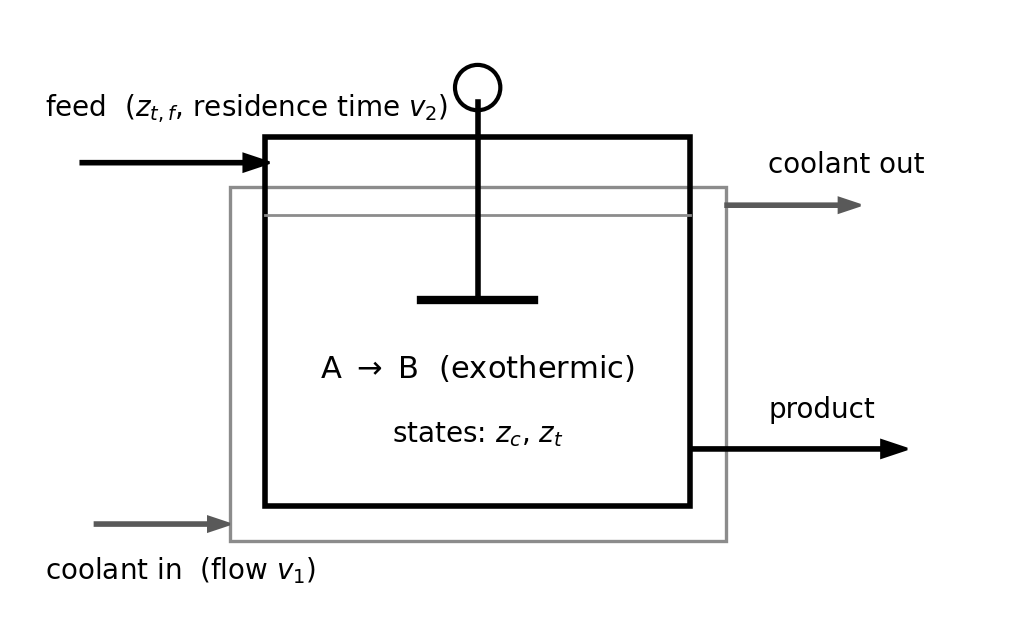

## The optimal control problem

Direct collocation (Radau, 3 points per element) over a horizon of
fifty one-unit sampling intervals. The controls are piecewise
constant, one move per interval, declared with pyomo-cvp before
discretization and parameterized after, so each control has one
decision variable per move. The objective is the tracking stage
cost toward the steady state (weights 10 and 2 on the states, 1 and
0.5 on the controls) plus a state-only terminal cost, the stage's
state terms (weights 10 and 2) scaled by 1000, which pins the
endpoint and suppresses the small end-of-horizon drift a finite
horizon otherwise allows. The initial
condition enters as two **mutable parameters**, `zc0` and `zt0`,
flagged with `declare_sens_param`: everything downstream
differentiates with respect to them.

In [1]:
import time

import matplotlib.pyplot as plt
import pyomo.environ as pyo
from pyomo.dae import ContinuousSet, DerivativeVar
from pyomo_cvp import control_value, declare_profile
import pyomo_pounce  # registers 'pounce' with SolverFactory
from pyomo_pounce import declare_sens_param, estimate, gradient

N, h = 50, 1

m = pyo.ConcreteModel()
m.t = ContinuousSet(initialize=pyo.RangeSet(0, N * h, h))

m.u1sf = pyo.Param(initialize=600)   # coolant-flow scale factor
m.u2sf = pyo.Param(initialize=40)    # residence-time scale factor
m.k0 = pyo.Param(initialize=300)     # Arrhenius pre-exponential
m.ea = pyo.Param(initialize=5)       # dimensionless activation energy
m.a0 = pyo.Param(initialize=1.95e-4)  # heat-transfer coefficient
m.ztcw = pyo.Param(initialize=0.38)  # coolant temperature
m.ztf = pyo.Param(initialize=0.395)  # feed temperature

m.zc_ss = pyo.Param(initialize=0.6416)   # steady-state targets
m.zt_ss = pyo.Param(initialize=0.5387)
m.v1_ss = pyo.Param(initialize=0.57828)
m.v2_ss = pyo.Param(initialize=0.49989)

# the initial condition: mutable, and the sensitivity parameters
m.zc0 = pyo.Param(initialize=0.625, mutable=True)
m.zt0 = pyo.Param(initialize=0.525, mutable=True)

m.zc = pyo.Var(m.t, bounds=(0, 1), initialize=0.6416)
m.zt = pyo.Var(m.t, bounds=(0, None), initialize=0.5387)
m.dzc = DerivativeVar(m.zc, wrt=m.t)
m.dzt = DerivativeVar(m.zt, wrt=m.t)
m.v1 = pyo.Var(m.t, bounds=(0.166666666666667, 1), initialize=0.57828)
m.v2 = pyo.Var(m.t, bounds=(0.025, 1), initialize=0.49989)
declare_profile(m.v1, m.v2, wrt=m.t, profile="piecewise_constant")


@m.Constraint(m.t)
def zc_ode(m, t):
    return m.dzc[t] == (1 - m.zc[t]) / (m.u2sf * m.v2[t]) - m.k0 * m.zc[t] * pyo.exp(-m.ea / m.zt[t])


@m.Constraint(m.t)
def zt_ode(m, t):
    return m.dzt[t] == (m.ztf - m.zt[t]) / (m.u2sf * m.v2[t]) + m.k0 * m.zc[t] * pyo.exp(-m.ea / m.zt[t]) - m.a0 * m.u1sf * m.v1[t] * (m.zt[t] - m.ztcw)


@m.Constraint()
def zc_init(m):
    return m.zc[0] == m.zc0


@m.Constraint()
def zt_init(m):
    return m.zt[0] == m.zt0


grid = sorted(m.t)


@m.Objective()
def obj(m):
    return sum(
        10 * (m.zc[t] - m.zc_ss) ** 2 + 2 * (m.zt[t] - m.zt_ss) ** 2
        + (m.v1[t] - m.v1_ss) ** 2 + 0.5 * (m.v2[t] - m.v2_ss) ** 2
        for t in grid[:-1]) + 1000 * (10 * (m.zc[grid[-1]] - m.zc_ss) ** 2 + 2 * (m.zt[grid[-1]] - m.zt_ss) ** 2)


pyo.TransformationFactory("dae.collocation").apply_to(
    m, wrt=m.t, nfe=N, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("cvp.parameterize").apply_to(m)
declare_sens_param(m.zc0, m.zt0)

t0 = time.perf_counter()
pyo.SolverFactory("pounce").solve(m, tee=True)
solve_seconds = time.perf_counter() - t0
print(f"\nsolved in {solve_seconds:.3f} s")

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) — drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.9.0, running with linear solver FERAL.



Number of nonzeros in equality constraint Jacobian...:     2865
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:      906

Total number of variables............................:      706
                     variables with only lower bounds:      151
                variables with lower and upper bounds:      251
                     variables with only upper bounds:        0
Total number of equality constraints.................:      606
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
   0  0.0000000e+00 1.66e-02 8.93e-01   -1.0 0.00e+00      - 0.00e+00 0.00e+00   0
   1  1.7087194e-01 1.82e-04 2.72e-01   -1.7 1.76e-01      - 7.2


solved in 1.260 s


## The optimal trajectories

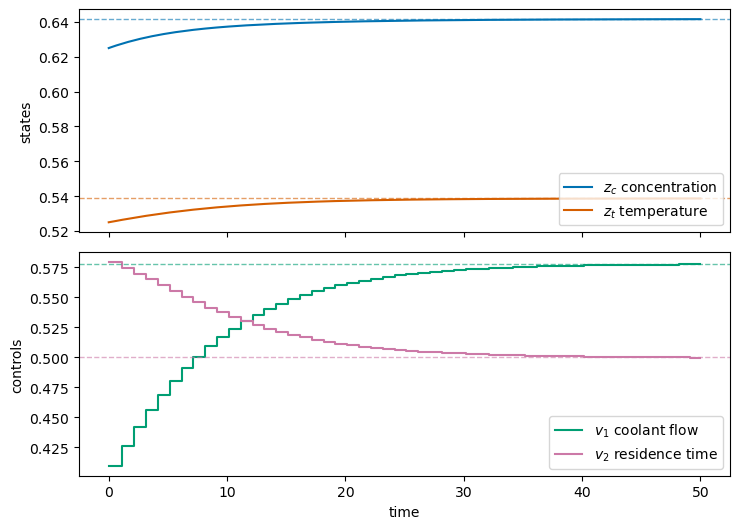

In [2]:
WONG = ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]

ts = sorted(m.t)
base = {
    "zc": [pyo.value(m.zc[t]) for t in ts],
    "zt": [pyo.value(m.zt[t]) for t in ts],
    "v1": [pyo.value(control_value(m.v1, t)) for t in ts],
    "v2": [pyo.value(control_value(m.v2, t)) for t in ts],
}

fig, (ax_z, ax_v) = plt.subplots(2, 1, figsize=(7.5, 5.4), sharex=True)
ax_z.plot(ts, base["zc"], color=WONG[0], label="$z_c$ concentration")
ax_z.plot(ts, base["zt"], color=WONG[1], label="$z_t$ temperature")
ax_z.axhline(pyo.value(m.zc_ss), color=WONG[0], ls="--", lw=1, alpha=0.6)
ax_z.axhline(pyo.value(m.zt_ss), color=WONG[1], ls="--", lw=1, alpha=0.6)
ax_z.set_ylabel("states")
ax_z.legend(loc="lower right")
ax_v.step(ts, base["v1"], where="post", color=WONG[2], label="$v_1$ coolant flow")
ax_v.step(ts, base["v2"], where="post", color=WONG[3], label="$v_2$ residence time")
ax_v.axhline(pyo.value(m.v1_ss), color=WONG[2], ls="--", lw=1, alpha=0.6)
ax_v.axhline(pyo.value(m.v2_ss), color=WONG[3], ls="--", lw=1, alpha=0.6)
ax_v.set_ylabel("controls")
ax_v.set_xlabel("time")
ax_v.legend(loc="lower right")
plt.tight_layout()
plt.show()

The same trajectory in the phase plane: from the initial condition
(dot) into the steady-state target (cross).

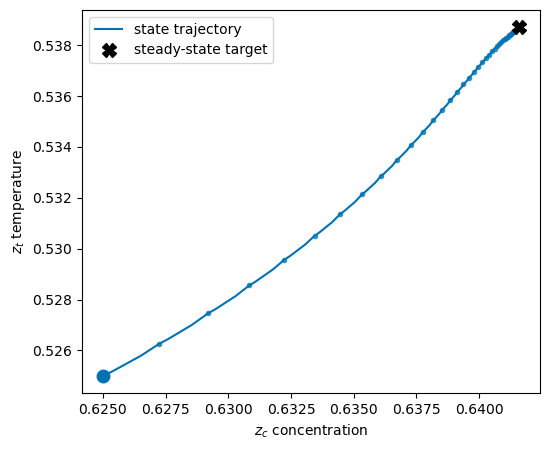

In [3]:
fig, ax = plt.subplots(figsize=(5.6, 4.6))
ax.plot(base["zc"], base["zt"], color=WONG[0], label="state trajectory")
samples = [t for t in ts if t == int(t)]
sample_idx = [ts.index(t) for t in samples]
ax.plot([base["zc"][k] for k in sample_idx],
        [base["zt"][k] for k in sample_idx],
        ".", color=WONG[0], ms=6, alpha=0.7)
ax.plot(pyo.value(m.zc0), pyo.value(m.zt0), "o", color=WONG[0], ms=9)
ax.plot(pyo.value(m.zc_ss), pyo.value(m.zt_ss), "X", color="k", ms=10,
        label="steady-state target")
ax.set_xlabel("$z_c$ concentration")
ax.set_ylabel("$z_t$ temperature")
ax.legend()
plt.tight_layout()
plt.show()

## The feedback gains

No extra solve happens here. The solver is still holding the KKT
factorization from the solve above, and each entry of the gain
matrix is one backsolve: the derivative of a first control move
with respect to one component of the initial state.

In [4]:
t0 = time.perf_counter()
K = [[gradient(v[0], wrt=p) for p in (m.zc0, m.zt0)]
     for v in (m.v1, m.v2)]
gain_seconds = time.perf_counter() - t0

print("Local feedback gains (first move w.r.t. initial state):\n")
print(f"              d/d zc0     d/d zt0")
print(f"  v1[0]   {K[0][0]:9.4f}   {K[0][1]:9.4f}")
print(f"  v2[0]   {K[1][0]:9.4f}   {K[1][1]:9.4f}")
print(f"\ncomputed in {gain_seconds * 1e6:.0f} microseconds")

Local feedback gains (first move w.r.t. initial state):

              d/d zc0     d/d zt0
  v1[0]      1.2441     10.8790
  v2[0]      1.9021     -6.8008

computed in 6759 microseconds


## A perturbed start: estimate versus re-solve

The plant never starts exactly where the last solve assumed. From
the held factorization, `estimate()` predicts the re-optimized
first moves at a perturbed initial state without any solver run;
the re-solve then shows how good that first-order prediction was,
and what the exact answer costs instead. The estimate is a
first-order Taylor step, so it is excellent near the solved point
and degrades as the perturbation grows: the app built on this
notebook lets you push it until it breaks.

In [5]:
zc0_new, zt0_new = 0.61, 0.54

t0 = time.perf_counter()
est = estimate(m, [(m.zc0, zc0_new), (m.zt0, zt0_new)])
estimate_seconds = time.perf_counter() - t0

m.zc0 = zc0_new
m.zt0 = zt0_new
t0 = time.perf_counter()
pyo.SolverFactory("pounce").solve(m)
resolve_seconds = time.perf_counter() - t0

print(f"perturbed start: zc0 = {zc0_new}, zt0 = {zt0_new}\n")
print(f"             estimate    re-solve")
print(f"  v1[0]   {est[m.v1[0]]:9.4f}   {pyo.value(m.v1[0]):9.4f}")
print(f"  v2[0]   {est[m.v2[0]]:9.4f}   {pyo.value(m.v2[0]):9.4f}")
print(f"\n  estimate: {estimate_seconds * 1e6:8.0f} microseconds")
print(f"  re-solve: {resolve_seconds * 1e6:8.0f} microseconds "
      f"({resolve_seconds / max(estimate_seconds, 1e-9):,.0f}x)")

perturbed start: zc0 = 0.61, zt0 = 0.54

             estimate    re-solve
  v1[0]      0.5541      0.5340
  v2[0]      0.4486      0.4119

  estimate:    25181 microseconds
  re-solve:   383329 microseconds (15x)


The factorization predicts more than the first move: `estimate()`
returns the first-order update of the **entire** re-optimized
solution. Below, the predicted trajectories (dashed) against the
exact re-solve (solid) from the perturbed start: everywhere they
overlap, a microsecond backsolve replaced a solver run.

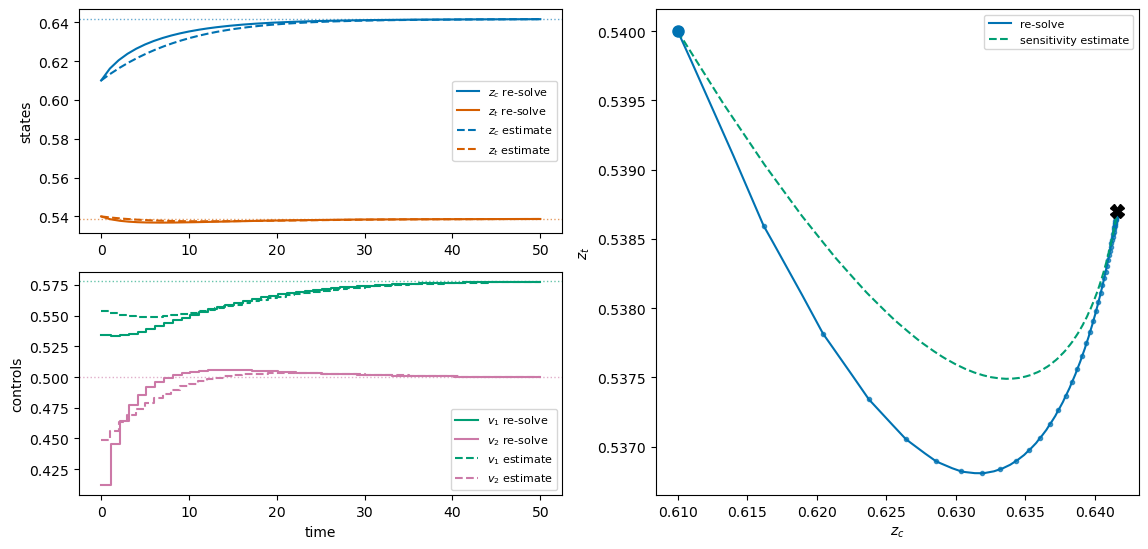

In [6]:
pert = {
    "zc": [pyo.value(m.zc[t]) for t in ts],
    "zt": [pyo.value(m.zt[t]) for t in ts],
    "v1": [pyo.value(control_value(m.v1, t)) for t in ts],
    "v2": [pyo.value(control_value(m.v2, t)) for t in ts],
}
pred = {
    "zc": [est[m.zc[t]] for t in ts],
    "zt": [est[m.zt[t]] for t in ts],
    # the governing move of a piecewise-constant control at time t
    # is the member at its element start
    "v1": [est[m.v1[min(int(t), N - 1)]] for t in ts],
    "v2": [est[m.v2[min(int(t), N - 1)]] for t in ts],
}

fig, axes = plt.subplot_mosaic(
    [["states", "phase"], ["controls", "phase"]],
    figsize=(11.5, 5.6))
axes["controls"].sharex(axes["states"])

ax = axes["states"]
ax.plot(ts, pert["zc"], color=WONG[0], label="$z_c$ re-solve")
ax.plot(ts, pert["zt"], color=WONG[1], label="$z_t$ re-solve")
ax.plot(ts, pred["zc"], color=WONG[0], ls="--", label="$z_c$ estimate")
ax.plot(ts, pred["zt"], color=WONG[1], ls="--", label="$z_t$ estimate")
ax.axhline(pyo.value(m.zc_ss), color=WONG[0], ls=":", lw=1, alpha=0.6)
ax.axhline(pyo.value(m.zt_ss), color=WONG[1], ls=":", lw=1, alpha=0.6)
ax.set_ylabel("states")
ax.legend(fontsize=8)

ax = axes["controls"]
ax.step(ts, pert["v1"], where="post", color=WONG[2], label="$v_1$ re-solve")
ax.step(ts, pert["v2"], where="post", color=WONG[3], label="$v_2$ re-solve")
ax.step(ts, pred["v1"], where="post", color=WONG[2], ls="--", label="$v_1$ estimate")
ax.step(ts, pred["v2"], where="post", color=WONG[3], ls="--", label="$v_2$ estimate")
ax.axhline(pyo.value(m.v1_ss), color=WONG[2], ls=":", lw=1, alpha=0.6)
ax.axhline(pyo.value(m.v2_ss), color=WONG[3], ls=":", lw=1, alpha=0.6)
ax.set_xlabel("time")
ax.set_ylabel("controls")
ax.legend(fontsize=8)

ax = axes["phase"]
ax.plot(pert["zc"], pert["zt"], color=WONG[0], label="re-solve")
ax.plot([pert["zc"][k] for k in sample_idx],
        [pert["zt"][k] for k in sample_idx],
        ".", color=WONG[0], ms=6, alpha=0.7)
ax.plot(pred["zc"], pred["zt"], color=WONG[2], ls="--", label="sensitivity estimate")
ax.plot(zc0_new, zt0_new, "o", color=WONG[0], ms=8)
ax.plot(pyo.value(m.zc_ss), pyo.value(m.zt_ss), "X", color="k", ms=10)
ax.set_xlabel("$z_c$")
ax.set_ylabel("$z_t$")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## References

- G.A. Hicks, W.H. Ray, Approximation methods for optimal control
  synthesis, Can. J. Chem. Eng. 49 (1971) 522-528.
- R. Huang, S.C. Patwardhan, L.T. Biegler, Robust stability of
  nonlinear model predictive control based on extended Kalman
  filter, J. Process Control 22 (2012) 82-89 (the dimensionless
  form used here).
- V.M. Zavala, L.T. Biegler, The advanced-step NMPC controller:
  optimality, stability and robustness, Automatica 45 (2009)
  86-93.
- H. Pirnay, R. Lopez-Negrete, L.T. Biegler, Optimal sensitivity
  based on IPOPT, Mathematical Programming Computation 4 (2012)
  307-331 (sIPOPT, the style of sensitivity system used here).
- [pyomo-cvp](https://pypi.org/project/pyomo-cvp/) and
  [pyomo-pounce](https://pypi.org/project/pyomo-pounce/).